In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [2]:
plt.rcParams['font.family']

['sans-serif']

In [3]:
infile = 'ForSimulation_Grade3_With_tokens.xlsx'
outfile = 'Simulation_Grade3_tokens.pdf'

In [4]:
parts = re.split(r'[._]', outfile)
print(parts)  # Output: ['example', 'file', 'name', 'txt']
title = parts[1]
title = title[:-1] + " " + title[-1].upper() + " Speakers" 

['Simulation', 'Grade3', 'tokens', 'pdf']


In [5]:
title = title [:] +" "+ "- Tokens"

In [6]:
title

'Grade 3 Speakers - Tokens'

In [7]:
df = pd.read_excel(infile)

In [8]:
df.columns

Index(['Class', 'Property', 'Lexical_p0', 'Experimental_phat', 'Raw_successes',
       'n_limiting', 'Token_p0'],
      dtype='object')

In [9]:
df.iloc[0:9]

,Class,Property,Lexical_p0,Experimental_phat,Raw_successes,n_limiting,Token_p0
0,aF,APU,0.167155,0.230453,56,27,0.135312
1,aF,PU,0.671554,0.724280,176,27,0.723852
2,iF,APU,0.467742,0.197531,48,27,0.369221
3,iF,PU,0.225806,0.679012,165,27,0.264725
4,iN,APU,0.004167,0.152263,37,27,0.000620
5,iN,PU,0.987500,0.757202,184,27,0.991945
6,isM,APU,0.055556,0.127572,31,27,0.023006
7,isM,PU,0.666667,0.674897,164,27,0.245399
8,maN,APU,0.999999,0.518519,126,27,1.000000


In [10]:
number_of_simulations = 1000
number_of_participants = df.iloc[0]['n_limiting'] 
print(f"Number of Participants: {number_of_participants}")
number_of_word_clusters = 9

Number of Participants: 27


In [11]:
rng = np.random.default_rng(16121968547)

In [12]:
person_bias = rng.normal(loc=0, scale=0.1, size=2) # Adds noise with mean 0 and stddev 0.1
print(person_bias)

[0.0786534  0.11372621]


In [13]:
df

,Class,Property,Lexical_p0,Experimental_phat,Raw_successes,n_limiting,Token_p0
0,aF,APU,0.167155,0.230453,56,27,0.135312
1,aF,PU,0.671554,0.724280,176,27,0.723852
2,iF,APU,0.467742,0.197531,48,27,0.369221
3,iF,PU,0.225806,0.679012,165,27,0.264725
4,iN,APU,0.004167,0.152263,37,27,0.000620
5,iN,PU,0.987500,0.757202,184,27,0.991945
6,isM,APU,0.055556,0.127572,31,27,0.023006
7,isM,PU,0.666667,0.674897,164,27,0.245399
8,maN,APU,0.999999,0.518519,126,27,1.000000
9,maN,PU,0.000001,0.460905,112,27,0.000000


In [14]:
lexical_dict = {}
for class_value in df['Class'].unique():
    apu_row = df[(df['Class'] == class_value) & (df['Property'] == 'APU')]
    pu_row = df[(df['Class'] == class_value) & (df['Property'] == 'PU')]
    apu_val = apu_row['Token_p0'].values[0] if not apu_row.empty else None
    pu_val = pu_row['Token_p0'].values[0] if not pu_row.empty else None
    lexical_dict[class_value] = [apu_val, pu_val]
print(lexical_dict)

{'aF': [np.float64(0.13531239212978943), np.float64(0.7238522609596134)], 'iF': [np.float64(0.3692210259658012), np.float64(0.26472450918302726)], 'iN': [np.float64(0.0006195786864931846), np.float64(0.9919454770755886)], 'isM': [np.float64(0.023006134969325152), np.float64(0.24539877300613497)], 'maN': [np.float64(1.0), np.float64(0.0)], 'oN': [np.float64(0.48), np.float64(0.4843076923076923)], 'osM': [np.float64(0.6763819095477388), np.float64(0.0864321608040201)]}


In [15]:
actual_results_dict = {}
for class_value in df['Class'].unique():
    apu_row = df[(df['Class'] == class_value) & (df['Property'] == 'APU')]
    pu_row = df[(df['Class'] == class_value) & (df['Property'] == 'PU')]
    apu_val = apu_row['Experimental_phat'].values[0] if not apu_row.empty else None
    pu_val = pu_row['Experimental_phat'].values[0] if not pu_row.empty else None
    actual_results_dict[class_value] = [apu_val, pu_val]
print(actual_results_dict)

{'aF': [np.float64(0.2304526748971193), np.float64(0.7242798353909465)], 'iF': [np.float64(0.1975308641975309), np.float64(0.6790123456790124)], 'iN': [np.float64(0.1522633744855967), np.float64(0.757201646090535)], 'isM': [np.float64(0.1275720164609054), np.float64(0.6748971193415638)], 'maN': [np.float64(0.5185185185185185), np.float64(0.4609053497942387)], 'oN': [np.float64(0.3703703703703703), np.float64(0.5555555555555556)], 'osM': [np.float64(0.3786008230452675), np.float64(0.4567901234567901)]}


In [16]:
def individual_experiment(number_of_word_clusters):
    result = {}
    person_bias = rng.normal(loc=0, scale=0.1, size=2) # Adds noise with mean 0 and stddev 0.1
    person_probs_dict = { k: [v[0] + person_bias[0], v[1] + person_bias[1], 1 - (v[0] + person_bias[0] + v[1] + person_bias[1])] for k, v in lexical_dict.items() }
    
    for k, v in person_probs_dict.items():
        a = min(max(v[0], 0), 1)
        b = min(max(v[1], 0), 1)
        c = 1 - (a + b)
        if c < 0:
            c = 0
            if a + b > 1:
                total = a + b
                a = a / total
                b = b / total
        person_probs_dict[k] = [a, b, c]

    for class_value in df['Class'].unique():
        #print(person_probs_dict[class_value])
        result[class_value] = rng.choice(3, size=number_of_word_clusters, p=person_probs_dict[class_value])
    return result
    

In [17]:
rs = individual_experiment(number_of_word_clusters)

In [18]:
rs

{'aF': array([0, 1, 1, 1, 1, 0, 1, 1, 0]),
 'iF': array([0, 0, 0, 1, 0, 0, 2, 2, 2]),
 'iN': array([1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'isM': array([2, 2, 2, 2, 2, 2, 2, 2, 0]),
 'maN': array([0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'oN': array([2, 0, 0, 0, 1, 0, 0, 0, 1]),
 'osM': array([0, 0, 0, 2, 2, 0, 0, 0, 0])}

In [19]:
def count_choices_per_class(results):
    counts_per_class = {}
    for class_value, choices in results.items():
        counts = Counter(choices)
        counts_per_class[class_value] = {
            'APU': counts.get(0, 0)/len(choices),
            'PU': counts.get(1, 0)/len(choices),
            'U': counts.get(2, 0)/len(choices)  
        }
    return counts_per_class

In [20]:
counts_per_class = count_choices_per_class(rs)
print(counts_per_class)

{'aF': {'APU': 0.3333333333333333, 'PU': 0.6666666666666666, 'U': 0.0}, 'iF': {'APU': 0.5555555555555556, 'PU': 0.1111111111111111, 'U': 0.3333333333333333}, 'iN': {'APU': 0.0, 'PU': 1.0, 'U': 0.0}, 'isM': {'APU': 0.1111111111111111, 'PU': 0.0, 'U': 0.8888888888888888}, 'maN': {'APU': 1.0, 'PU': 0.0, 'U': 0.0}, 'oN': {'APU': 0.6666666666666666, 'PU': 0.2222222222222222, 'U': 0.1111111111111111}, 'osM': {'APU': 0.7777777777777778, 'PU': 0.0, 'U': 0.2222222222222222}}


In [21]:
def complete_experiment(number_of_participants, number_of_word_clusters):
    combined_results = {class_value: [] for class_value in df['Class'].unique()}
    for _ in range(number_of_participants):
        rs = individual_experiment(number_of_word_clusters)
        for class_value in df['Class'].unique():
            combined_results[class_value].extend(rs[class_value])
    return combined_results

In [22]:
combined_results = complete_experiment(number_of_participants, number_of_word_clusters)

In [23]:
for class_value, choices in combined_results.items():
    print(f"Class: {class_value}, Choices: {len(choices)}")

Class: aF, Choices: 243
Class: iF, Choices: 243
Class: iN, Choices: 243
Class: isM, Choices: 243
Class: maN, Choices: 243
Class: oN, Choices: 243
Class: osM, Choices: 243


In [24]:
counts_per_class = count_choices_per_class(combined_results)
print(counts_per_class)

{'aF': {'APU': 0.1111111111111111, 'PU': 0.6872427983539094, 'U': 0.20164609053497942}, 'iF': {'APU': 0.3991769547325103, 'PU': 0.24279835390946503, 'U': 0.35802469135802467}, 'iN': {'APU': 0.06172839506172839, 'PU': 0.8888888888888888, 'U': 0.04938271604938271}, 'isM': {'APU': 0.09465020576131687, 'PU': 0.205761316872428, 'U': 0.6995884773662552}, 'maN': {'APU': 0.9259259259259259, 'PU': 0.03292181069958848, 'U': 0.0411522633744856}, 'oN': {'APU': 0.4609053497942387, 'PU': 0.4279835390946502, 'U': 0.1111111111111111}, 'osM': {'APU': 0.654320987654321, 'PU': 0.0823045267489712, 'U': 0.26337448559670784}}


In [25]:
simulation_results = {class_value: [] for class_value in df['Class'].unique()}
for _ in range(number_of_simulations):
    combined_results = complete_experiment(number_of_participants, number_of_word_clusters)
    counts_per_class = count_choices_per_class(combined_results)
    for class_value in df['Class'].unique():
        x = counts_per_class[class_value]['APU']
        y = counts_per_class[class_value]['PU']
        simulation_results[class_value].append((x, y))
print(simulation_results)

{'aF': [(0.102880658436214, 0.720164609053498), (0.14814814814814814, 0.6790123456790124), (0.16049382716049382, 0.6872427983539094), (0.11522633744855967, 0.7078189300411523), (0.15637860082304528, 0.7325102880658436), (0.12345679012345678, 0.7160493827160493), (0.12757201646090535, 0.7242798353909465), (0.1934156378600823, 0.6584362139917695), (0.09465020576131687, 0.757201646090535), (0.21810699588477367, 0.6296296296296297), (0.1440329218106996, 0.691358024691358), (0.13580246913580246, 0.7407407407407407), (0.1111111111111111, 0.7489711934156379), (0.12757201646090535, 0.7366255144032922), (0.12757201646090535, 0.691358024691358), (0.11522633744855967, 0.7160493827160493), (0.12345679012345678, 0.7037037037037037), (0.09053497942386832, 0.7242798353909465), (0.13168724279835392, 0.720164609053498), (0.09876543209876543, 0.7119341563786008), (0.1728395061728395, 0.6831275720164609), (0.15637860082304528, 0.6790123456790124), (0.09053497942386832, 0.7860082304526749), (0.13168724279

In [26]:
# Prepare DataFrame for plotting
plot_data = []
for class_value, points in simulation_results.items():
    for x, y in points:
        plot_data.append({'Class': class_value, 'APU': x, 'PU': y})
df_plot = pd.DataFrame(plot_data)

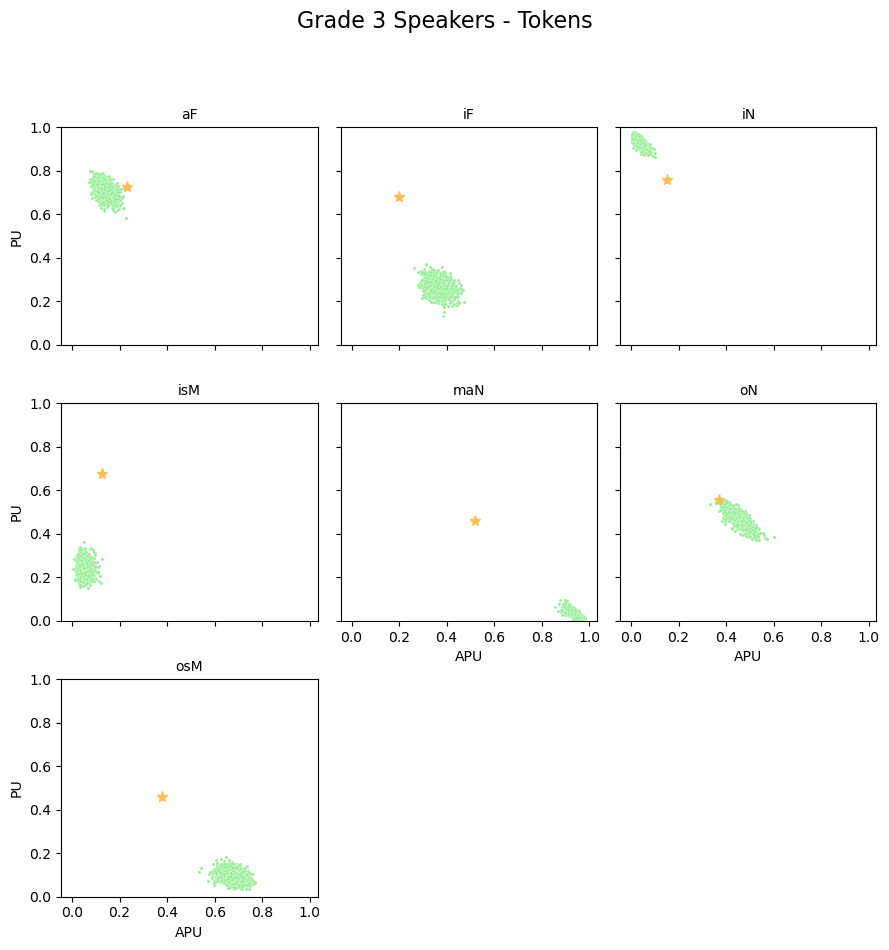

In [31]:
g = sns.FacetGrid(df_plot, col='Class', col_wrap=3, sharex=True, sharey=True, despine=False)
g.map_dataframe(sns.scatterplot, x='APU', y='PU',color='lightgreen', s=5, marker='o' )

# Ensure vertical axis includes 1.0 tick
g.set(ylim=(0, 1))
yticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
xticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
for ax in g.axes.flat:
    ax.set_yticks(yticks)
    ax.set_xticks(xticks)

# Add yellow star for actual results
for ax, class_value in zip(g.axes.flat, df_plot['Class'].unique()):
    actual = actual_results_dict[class_value]
    ax.plot(actual[0], actual[1], marker='*', color='#ffbd58', markersize=8, label='Actual')
    # ax.legend()

g.set_axis_labels('APU', 'PU')
g.set_titles(col_template="{col_name}")
plt.suptitle(title, fontsize=16, y=1.05)
plt.savefig(outfile, bbox_inches='tight')
plt.tight_layout()
plt.show()